### RNA Polymerase II serine 2 phosphorylation

In [7]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyBigWig
import seaborn as sns
from scipy.stats import zscore
from sklearn.decomposition import PCA
# PDF settings
plt.rcParams['pdf.fonttype'] = 42
os.getcwd()

'/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2'

### PCA

['chr', 'start', 'end', 'UT_rep1', 'UT_rep2', 'E6_rep1', 'E6_rep2', 'E6R6_rep1', 'E6R6_rep2']
Samples used: ['UT_rep1', 'UT_rep2', 'E6_rep1', 'E6_rep2', 'E6R6_rep1', 'E6R6_rep2']
    Variable        PC1        PC2        PC3        PC4        PC5  \
0    UT_rep1 -24.853436  70.058940 -35.235027 -21.021846 -18.190138   
1    UT_rep2 -10.859721   4.801934  -0.842988  10.129305  72.085264   
2    E6_rep1 -45.681785 -63.608634 -18.704209 -34.383811 -12.257350   
3    E6_rep2 -14.152792  -8.451698   1.158882  75.434890 -24.313481   
4  E6R6_rep1   6.298132  11.839100  78.464773 -21.411007 -11.728346   
5  E6R6_rep2  89.249603 -14.639642 -24.841431  -8.747533  -5.595949   

            PC6 condition replicate  
0  2.212241e-14        UT      rep1  
1  2.212241e-14        UT      rep2  
2  2.212241e-14        E6      rep1  
3  2.212241e-14        E6      rep2  
4  2.212241e-14      E6R6      rep1  
5  2.212241e-14      E6R6      rep2  


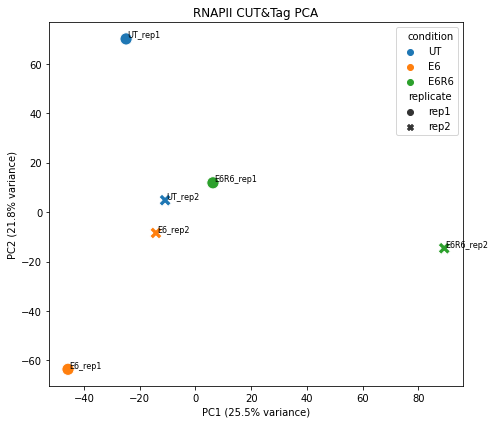

In [8]:
plt.rcParams['pdf.fonttype'] = 42

# ── 1. Load raw counts matrix from multiBigwigSummary ──────────────────
# Typical deepTools --outRawCounts format:
#   #'chr'   'start'   'end'   'UT_rep1'   'UT_rep2'  ...
raw = pd.read_csv("../../pca/rnapii_matrix.tab", sep="\t")

# clean up column names (deepTools often wraps them in quotes, prefixes '#')
raw.columns = [c.strip("#' ") for c in raw.columns]
print(raw.columns.tolist())

# first 3 columns should be chr/start/end
region_cols = raw.columns[:3].tolist()
sample_cols = raw.columns[3:].tolist()

print("Samples used:", sample_cols)

counts = raw[sample_cols]

# ── 2. Log-transform ─────────────────────────────────────────────────
log_counts = np.log2(counts + 1)

# ── 3. Run PCA (samples as rows, regions as features) ──────────────────
X = log_counts.T.values  # transpose: rows = samples, cols = regions

pca = PCA(n_components=min(len(sample_cols), 10))
pc_scores = pca.fit_transform(X)

pct_var = (pca.explained_variance_ratio_ * 100).round(1)

pca_df = pd.DataFrame(
    pc_scores,
    columns=[f"PC{i+1}" for i in range(pc_scores.shape[1])],
    index=sample_cols
)
pca_df.index.name = "Variable"
pca_df = pca_df.reset_index()

# ── 4. Split condition / replicate ──────────────────────────────────
split_vars = pca_df["Variable"].str.split("_")
pca_df["condition"] = split_vars.str[0]
pca_df["replicate"] = split_vars.str[1]

print(pca_df)

# ── 5. Plot PC1 vs PC2 ───────────────────────────────────────────────
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="condition", style="replicate",
    s=150
)
for _, row in pca_df.iterrows():
    plt.text(row["PC1"] + 0.5, row["PC2"] + 0.5, row["Variable"], fontsize=8)
    
    


plt.xlabel(f"PC1 ({pct_var[0]}% variance)")
plt.ylabel(f"PC2 ({pct_var[1]}% variance)")
plt.title("RNAPII CUT&Tag PCA")
plt.tight_layout()
plt.savefig("../../pca/rnapii_PCA_python_norep1.pdf")
plt.show()

### Genes with TPM from RNA-seq

In [9]:
TPMdfrpath = "/Zulu/bnolan/Projects/Personal/Ethanol/Assays/RNA-seq/ENCODE_CDE_4-21/allnoNA_genes_16k_TPM.tsv"
TPMdfr = pd.read_csv(TPMdfrpath, sep="\t", header=0)

In [10]:
TPMdfr.columns

Index(['baseMean_ethanol', 'log2FoldChange_ethanol', 'lfcSE_ethanol',
       'stat_ethanol', 'pvalue_ethanol', 'padj_ethanol', 'GeneSymbol',
       'Chromosome', 'Start', 'End', 'Class', 'Strand', 'Length',
       'baseMean_withdrawal', 'log2FoldChange_withdrawal', 'lfcSE_withdrawal',
       'stat_withdrawal', 'pvalue_withdrawal', 'padj_withdrawal', 'status',
       'UT_mean', 'E6_mean', 'E6R6_mean'],
      dtype='object')

### Bigwigs

In [11]:
bwigs = "/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2"

In [12]:
GENE_COL = "GeneSymbol"      # gene identifier / symbol column (rownames from R)
CHROM_COL = "Chromosome"
START_COL = "Start"
END_COL = "End"
STRAND_COL = "Strand"
UT_TPM_COL = "UT_mean"       # control mean TPM column
 
TPMdfr = TPMdfr.rename(columns={GENE_COL: "gene"})
 
# ----------------------------------------------------------------------
# 1. BIN GENES BY CONTROL TPM
# ----------------------------------------------------------------------
bin_edges = [0, 1, 5, 10, 20, 50]
bin_labels = ["0-1", "1-5", "5-10", "10-20", "20-50"]
 
TPMdfr["TPM_group"] = pd.cut(
    TPMdfr[UT_TPM_COL],
    bins=bin_edges,
    labels=bin_labels,
    right=False,       # [0,1), [1,5), [5,10), [10,20), [20,50)
    include_lowest=False
)
 
# Drop genes with TPM == 0 or > 50 or missing coordinates (not in any bin)
TPMdfr = TPMdfr.dropna(subset=["TPM_group", CHROM_COL, START_COL, END_COL, STRAND_COL])
 
print(TPMdfr["TPM_group"].value_counts().reindex(bin_labels))
 


0-1      2595
1-5      3874
5-10     2368
10-20    2826
20-50    2703
Name: TPM_group, dtype: int64


### Write out TPM groups to files so we can use computeMatrix

In [13]:
GENE_OUT_COL = "gene"

output_dir = "/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files"
os.makedirs(output_dir, exist_ok=True)

output_cols = [CHROM_COL, START_COL, END_COL, GENE_OUT_COL, "TPM_group", STRAND_COL]

for grp in bin_labels:
    sub = TPMdfr.loc[TPMdfr["TPM_group"] == grp, output_cols].copy()
    sub[START_COL] = sub[START_COL].astype(int)
    sub[END_COL] = sub[END_COL].astype(int)

    out_path = os.path.join(output_dir, f"TPM_group_{grp}.bed")
    sub.to_csv(out_path, sep="\t", header=False, index=False)
    print(f"{grp}: {len(sub)} genes -> {out_path}")

0-1: 2595 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/TPM_group_0-1.bed
1-5: 3874 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/TPM_group_1-5.bed
5-10: 2368 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/TPM_group_5-10.bed
10-20: 2826 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/TPM_group_10-20.bed
20-50: 2703 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/TPM_group_20-50.bed


In [14]:
TPMdfr

,baseMean_ethanol,log2FoldChange_ethanol,lfcSE_ethanol,stat_ethanol,pvalue_ethanol,padj_ethanol,gene,Chromosome,Start,End,...,log2FoldChange_withdrawal,lfcSE_withdrawal,stat_withdrawal,pvalue_withdrawal,padj_withdrawal,status,UT_mean,E6_mean,E6R6_mean,TPM_group
7SK,17.286897,-7.408692,3.245207,-2.282964,0.022432,0.087219,7SK,chr1,120228046,120228295,...,-0.275949,3.028747,-0.091110,0.927405,0.965489,NS,4.446667,0.000000,5.010000,1-5
A2M-AS1,17.213294,-0.856268,0.571314,-1.498769,0.133934,0.300590,A2M-AS1,chr12,9065163,9068689,...,-0.190075,0.555241,-0.342329,0.732104,0.856478,NS,0.500000,0.313333,0.530000,0-1
A4GALT,296.956735,0.201055,0.172223,1.167409,0.243045,0.443246,A4GALT,chr22,42692121,42721298,...,-0.122129,0.174194,-0.701107,0.483236,0.685825,NS,7.700000,10.283333,8.203333,5-10
AACS,457.164144,-0.176120,0.165362,-1.065053,0.286852,0.492646,AACS,chr12,125065434,125143333,...,0.141124,0.164779,0.856443,0.391753,0.608265,NS,7.246667,7.446667,9.290000,5-10
AACSP1,77.433033,-0.046951,0.258769,-0.181440,0.856022,0.926852,AACSP1,chr5,178764861,178818435,...,0.872801,0.249498,3.498233,0.000468,0.005567,>1.5-fold,1.190000,1.336667,2.493333,1-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXDB,360.847056,0.048627,0.172806,0.281397,0.778406,0.882479,ZXDB,chrX,57592011,57597477,...,0.131233,0.172935,0.758857,0.447938,0.657014,NS,2.693333,3.270000,3.456667,1-5
ZXDC,632.529058,0.147795,0.164190,0.900142,0.368045,0.573963,ZXDC,chr3,126437601,126475891,...,-0.011678,0.164750,-0.070881,0.943493,0.972958,NS,9.546667,12.393333,11.103333,5-10
ZYG11B,1453.805975,0.280991,0.113600,2.473510,0.013379,0.059781,ZYG11B,chr1,52726453,52827336,...,0.160897,0.113919,1.412380,0.157838,0.345476,NS,7.600000,10.720000,9.793333,5-10
ZZEF1,1086.942445,-0.284003,0.151763,-1.871366,0.061294,0.175686,ZZEF1,chr17,4004445,4143030,...,-0.195462,0.152158,-1.284603,0.198931,0.401664,NS,10.203333,9.803333,10.386667,10-20


### Genes split by TPM but promoter +/- 1,000bp

In [53]:
GENE_COL = "GeneSymbol"      # gene identifier / symbol column (rownames from R)
CHROM_COL = "Chromosome"
START_COL = "Start"
END_COL = "End"
STRAND_COL = "Strand"
UT_TPM_COL = "UT_mean"       # control mean TPM column

TPMdfr = TPMdfr.rename(columns={GENE_COL: "gene"})

# ----------------------------------------------------------------------
# 1. BIN GENES BY CONTROL TPM
# ----------------------------------------------------------------------
bin_edges = [0, 1, 5, 10, 20, 50]
bin_labels = ["0-1", "1-5", "5-10", "10-20", "20-50"]

TPMdfr["TPM_group"] = pd.cut(
    TPMdfr[UT_TPM_COL],
    bins=bin_edges,
    labels=bin_labels,
    right=False,       # [0,1), [1,5), [5,10), [10,20), [20,50)
    include_lowest=False
)

# Drop genes with TPM == 0 or > 50 or missing coordinates (not in any bin)
TPMdfr = TPMdfr.dropna(subset=["TPM_group", CHROM_COL, START_COL, END_COL, STRAND_COL])

print(TPMdfr["TPM_group"].value_counts().reindex(bin_labels))

# ----------------------------------------------------------------------
# 2. DETERMINE TSS FROM STRAND, WINDOW +/-1kb
# ----------------------------------------------------------------------
PROMOTER_FLANK = 1000  # bp on each side of the TSS

GENE_OUT_COL = "gene"

TSS = TPMdfr[START_COL].where(TPMdfr[STRAND_COL] == "+", TPMdfr[END_COL])

TPMdfr["promoter_start"] = (TSS - PROMOTER_FLANK).clip(lower=0).astype(int)
TPMdfr["promoter_end"] = (TSS + PROMOTER_FLANK).astype(int)

output_cols = [CHROM_COL, "promoter_start", "promoter_end", GENE_OUT_COL, "TPM_group", STRAND_COL]

output_dir = "/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files"
promoter_dir = os.path.join(output_dir, "promoter")
os.makedirs(promoter_dir, exist_ok=True)

for grp in bin_labels:
    sub = TPMdfr.loc[TPMdfr["TPM_group"] == grp, output_cols].copy()
    out_path = os.path.join(promoter_dir, f"TPM_group_{grp}_promoter.bed")
    sub.to_csv(out_path, sep="\t", header=False, index=False)
    print(f"{grp}: {len(sub)} genes -> {out_path}")

0-1      2595
1-5      3874
5-10     2368
10-20    2826
20-50    2703
Name: TPM_group, dtype: int64
0-1: 2595 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/promoter/TPM_group_0-1_promoter.bed
1-5: 3874 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/promoter/TPM_group_1-5_promoter.bed
5-10: 2368 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/promoter/TPM_group_5-10_promoter.bed
10-20: 2826 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/promoter/TPM_group_10-20_promoter.bed
20-50: 2703 genes -> /Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/TPM_bed_files/promoter/TPM_group_20-50_promoter.bed


### Motif gained knownResults from Ethanol versus Control

In [13]:
RNAPIIgained = "/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2/homer/motif_above/knownResults.txt"
RNAPIIlost = "/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2/homer/motif_below/knownResults.txt"

In [14]:
RNAPIIgaineddf = pd.read_csv(RNAPIIgained, header=0, sep="\t")
RNAPIIgaineddf.columns

Index(['Motif Name', 'Consensus', 'P-value', 'Log P-value',
       'q-value (Benjamini)', '# of Target Sequences with Motif(of 311)',
       '% of Target Sequences with Motif',
       '# of Background Sequences with Motif(of 49293)',
       '% of Background Sequences with Motif'],
      dtype='object')

Top 5 Motifs - Pol II Gained
                                          Motif Name             Consensus  \
0   CTCF(Zf)/CD4+-CTCF-ChIP-Seq(Barski_et_al.)/Homer  AYAGTGCCMYCTRGTGGCCA   
1      BORIS(Zf)/K562-CTCFL-ChIP-Seq(GSE32465)/Homer  CNNBRGCGCCCCCTGSTGGC   
2     Fra1(bZIP)/BT549-Fra1-ChIP-Seq(GSE46166)/Homer          NNATGASTCATH   
3       Atf3(bZIP)/GBM-ATF3-ChIP-Seq(GSE33912)/Homer          DATGASTCATHN   
4  Fra2(bZIP)/Striatum-Fra2-ChIP-Seq(GSE43429)/Homer          GGATGACTCATC   

        P-value % of Target Sequences with Motif  \
0  1.000000e-44                           17.36%   
1  1.000000e-39                           20.58%   
2  1.000000e-04                            9.00%   
3  1.000000e-04                            9.65%   
4  1.000000e-03                            7.72%   

   # of Background Sequences with Motif(of 49293)  
0                                           571.8  
1                                          1160.5  
2                                

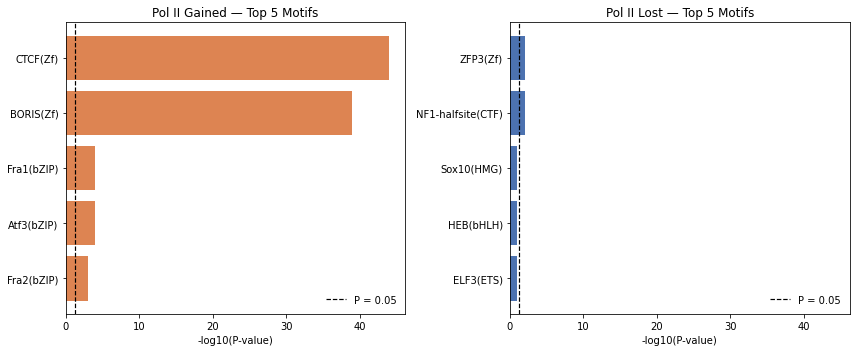

In [15]:
col_idx = [0, 1, 2, 6, 7]

gained_df = pd.read_csv(RNAPIIgained, sep="\t", header=0).iloc[:, col_idx]
lost_df = pd.read_csv(RNAPIIlost, sep="\t", header=0).iloc[:, col_idx]

# Sort by P-value ascending (most significant first) and take top 5
gained_top5 = gained_df.sort_values("P-value").head(5).reset_index(drop=True)
lost_top5 = lost_df.sort_values("P-value").head(5).reset_index(drop=True)

print("Top 5 Motifs - Pol II Gained")
print(gained_top5)
print("\nTop 5 Motifs - Pol II Lost")
print(lost_top5)

# -log10(P-value) for plotting
gained_top5["neg_log10_p"] = -np.log10(gained_top5["P-value"])
lost_top5["neg_log10_p"] = -np.log10(lost_top5["P-value"])

# HOMER motif names are long (e.g. "AP-1(bZIP)/ThioMac-PU.1-ChIP..."); 
# take just the short motif family name before the first "/" for cleaner labels
gained_top5["short_name"] = gained_top5["Motif Name"].str.split("/").str[0]
lost_top5["short_name"] = lost_top5["Motif Name"].str.split("/").str[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

axes[0].barh(gained_top5["short_name"], gained_top5["neg_log10_p"], color="#DD8452")
axes[0].invert_yaxis()
axes[0].set_title("Pol II Gained — Top 5 Motifs")
axes[0].set_xlabel("-log10(P-value)")

axes[1].barh(lost_top5["short_name"], lost_top5["neg_log10_p"], color="#4C72B0")
axes[1].invert_yaxis()
axes[1].set_title("Pol II Lost — Top 5 Motifs")
axes[1].set_xlabel("-log10(P-value)")


sig_threshold = -np.log10(0.05)

for ax in axes:
    ax.axvline(sig_threshold, color="black", linestyle="--", linewidth=1.2, label="P = 0.05")
    ax.legend(loc="lower right", frameon=False)
    
plt.tight_layout()
plt.savefig("/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2/homer/motif_top5_barplot.pdf", dpi=300)


### Annotations for gained and lost peaks

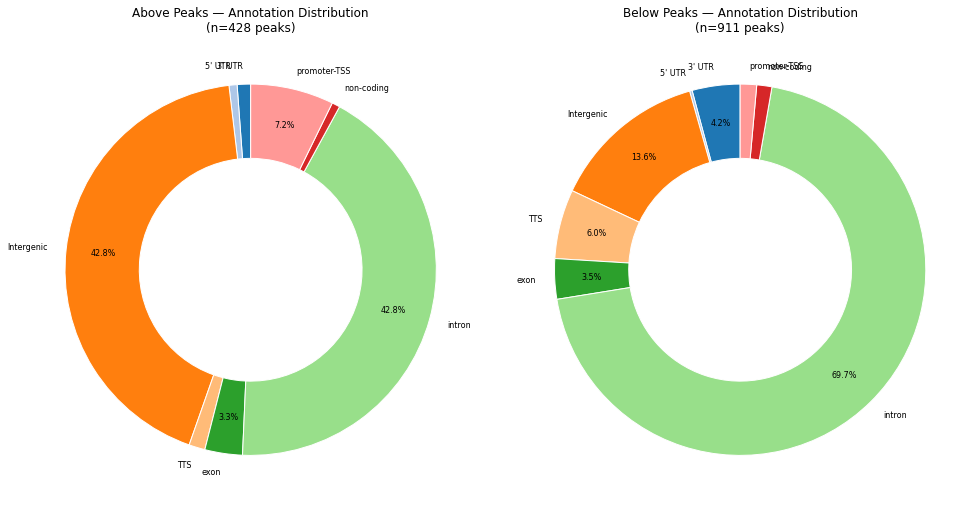

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

files = {
    "Above": "~/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2/homer/above_peaks.tsv",
    "Below": "~/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2/homer/below_peaks.tsv",
}

def clean_annotation(series):
    return series.str.partition(" (")[0].str.strip()

data = {}
for label, path in files.items():
    df = pd.read_csv(path, sep="\t", header=0)
    ann_col = df.columns[7]  # column 8, 1-indexed -> index 7
    counts = clean_annotation(df[ann_col]).value_counts()
    data[label] = counts

# Build one master, sorted list of all categories seen across both files,
# so color assignment doesn't depend on each file's own value_counts() order
all_categories = sorted(set(data["Above"].index) | set(data["Below"].index))

palette = plt.cm.tab20.colors
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(all_categories)}

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, (label, counts) in zip(axes, data.items()):
    counts = counts.reindex(all_categories).dropna()  # keep consistent category order too
    slice_colors = [color_map[cat] for cat in counts.index]

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
        pctdistance=0.8,
        colors=slice_colors,
        startangle=90,
        wedgeprops=dict(width=0.4, edgecolor="white"),
    )
    ax.set_title(f"{label} Peaks — Annotation Distribution\n(n={int(counts.sum())} peaks)")
    plt.setp(autotexts, size=8, color="black")
    plt.setp(texts, size=8)

plt.tight_layout()
plt.savefig("/Zulu/bnolan/Projects/Personal/Ethanol/Integrative_analysis/RNAPII/polII_goodreps/bams/deduped/pol2/homer/annotation_donut_charts.pdf", dpi=300)
plt.show()

### 17 TF binding profiles RNAPII heatmap

In [17]:
bwigs
"pol2.bw"
"pol2eth.bw"
"pol2ethwith.bw"

'pol2ethwith.bw'

### peaks = 18 TFs

ls peaks/*bed
peaks/CBX3_ENCFF423XAH.bed   peaks/ELF1_ENCFF420PYW.bed   peaks/POLR2A_ENCFF848IHI.bed  peaks/SRF_ENCFF502RNC.bed     peaks/YY1_ENCFF451EDW.bed
peaks/CEBPB_ENCFF963FVR.bed  peaks/FOSL1_ENCFF936WPZ.bed  peaks/RAD21_ENCFF391AAM.bed   peaks/TCF7L2_ENCFF845TYG.bed  peaks/ZBTB33_ENCFF141RIH.bed
peaks/CTCF_ENCFF832INR.bed   peaks/JUND_ENCFF378LWF.bed   peaks/SIN3A_ENCFF493SWH.bed   peaks/TEAD4_ENCFF008LFE.bed   peaks/ZFX_ENCFF858YWR.bed
peaks/EGR1_ENCFF822VKJ.bed   peaks/MAX_ENCFF214KLO.bed    peaks/SP1_ENCFF600MKH.bed     peaks/USF1_ENCFF725PAR.bed


#### Replaced above with computeMatrix. This didn't work as intended because the UT is broader but E6 has a sharper peak

### Read in the computeMatrix gz file

In [26]:
allpeaksTFmatrix = "peaks/pol2_allTFs.gz"

In [47]:
"""
Read a deepTools computeMatrix .gz matrix (reference-point mode, TF peaks as
region groups, Pol II conditions as samples), pull the signal value at the
peak center for every peak, average per TF, z-score each condition across
TFs, and plot the ranked z-scores as 'RNAPII occupancy at TF rank'.

No dependency on the deeptools python package's internal heatmapper class
(API varies across versions) -- this parses the matrix format directly,
which is stable and documented: a '@'-prefixed JSON header line followed by
tab-separated rows of [chrom, start, end, name, score, strand, bin values...].
"""

import gzip
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# >>> UPDATE THIS PATH <<<
# ----------------------------------------------------------------------
MATRIX_PATH = "peaks/pol2_allTFs.gz"

# If your --samplesLabel used different names than these, or you want
# nicer display names, map them here.
CONDITION_LABEL_MAP = {"pol2": "Control", "pol2eth": "Ethanol", "pol2ethwith": "Withdrawal"}

CONTROL_LABEL = "Control"  # must match a value in CONDITION_LABEL_MAP (or raw sample label) after mapping

# ----------------------------------------------------------------------
# 1. PARSE THE MATRIX FILE
# ----------------------------------------------------------------------
with gzip.open(MATRIX_PATH, "rt") as f:
    header_line = f.readline()
    header_json = json.loads(header_line.lstrip("@"))
    data = pd.read_csv(f, sep="\t", header=None, low_memory=False)

sample_labels_raw = header_json["sample_labels"]
sample_boundaries = header_json["sample_boundaries"]   # cumulative bin index per sample, e.g. [0,160,320,480]
group_labels = header_json["group_labels"]              # TF names, in -R file order
group_boundaries = header_json["group_boundaries"]      # cumulative row index per TF group
upstream = header_json["upstream"]
bin_size = header_json["bin size"]

sample_labels = [CONDITION_LABEL_MAP.get(s, s) for s in sample_labels_raw]

print("Sample labels found:", sample_labels_raw, "-> mapped to:", sample_labels)
print("TF groups found:", group_labels)
print(f"upstream={upstream}bp, bin_size={bin_size}bp")

if CONTROL_LABEL not in sample_labels:
    raise ValueError(
        f"CONTROL_LABEL='{CONTROL_LABEL}' not found in mapped sample labels {sample_labels}. "
        "Fix CONDITION_LABEL_MAP / CONTROL_LABEL above."
    )

N_META_COLS = 6  # chrom, start, end, name, score, strand
WINDOW_BP = 50    # +/- window around the reference point to average over

# ----------------------------------------------------------------------
# 2. EXTRACT MEAN SIGNAL IN A +/-WINDOW_BP WINDOW AROUND THE CENTER, PER SAMPLE
# ----------------------------------------------------------------------
# A single bin was tie-heavy when the bigwig's native resolution was coarser
# than the matrix binSize (many "different" bins just repeating the same
# underlying value). Averaging a small window around the reference point
# fixes that without smoothing so much that a genuinely sharp Ethanol-only
# peak gets diluted into its flanks -- 50bp is a fraction of a typical
# ChIP peak width, so real narrow signal should still come through.
center_values = {}  # {condition: np.array of length n_regions}
for i, (sample_raw, sample_label) in enumerate(zip(sample_labels_raw, sample_labels)):
    sample_upstream = upstream[i]
    sample_bin_size = bin_size[i]
    center_idx_within_sample = sample_upstream // sample_bin_size

    window_bins = max(1, WINDOW_BP // sample_bin_size)
    lo = max(0, center_idx_within_sample - window_bins)
    hi = center_idx_within_sample + window_bins  # inclusive via +1 below

    sample_start_bin = sample_boundaries[i]
    col_lo = N_META_COLS + sample_start_bin + lo
    col_hi = N_META_COLS + sample_start_bin + hi + 1  # +1 for inclusive slicing

    window_vals = data.iloc[:, col_lo:col_hi].apply(pd.to_numeric, errors="coerce")
    center_values[sample_label] = window_vals.mean(axis=1, skipna=True).values

# ----------------------------------------------------------------------
# 3. AVERAGE CENTER-BIN VALUE PER TF GROUP, PER CONDITION
# ----------------------------------------------------------------------
records = []
for g_idx, tf in enumerate(group_labels):
    row_start, row_end = group_boundaries[g_idx], group_boundaries[g_idx + 1]
    rec = {"TF": tf, "n_peaks": row_end - row_start}
    for cond, vals in center_values.items():
        rec[cond] = np.nanmean(vals[row_start:row_end])
    records.append(rec)

tf_means = pd.DataFrame(records).set_index("TF")

# Drop POLR2A (Pol II itself, not a TF of interest for this ranking)
tf_means = tf_means[~tf_means.index.str.contains("POLR2A")]

# Clean names to the part before the first underscore, e.g.
# "CBX3_ENCFF423XAH.bed" -> "CBX3", for axis labels / indexing from here on
tf_means.index = tf_means.index.str.split("_").str[0]

print(tf_means)

# ----------------------------------------------------------------------
# 4. Z-SCORE EACH CONDITION ACROSS TFs
# ----------------------------------------------------------------------
condition_cols = list(center_values.keys())
zscores = tf_means[condition_cols].apply(lambda col: (col - col.mean()) / col.std(), axis=0)
zscores.columns = [f"z_{c}" for c in zscores.columns]

# order TFs by control z-score, highest first
zscores = zscores.sort_values(f"z_{CONTROL_LABEL}", ascending=False)
tf_order = zscores.index.tolist()

print(zscores)

# ----------------------------------------------------------------------
# 5. PLOT: 'RNAPII occupancy at TF rank'
# ----------------------------------------------------------------------
palette = {"Control": "#4C72B0", "Ethanol": "#DD8452", "Withdrawal": "#55A868"}
x_positions = np.arange(len(tf_order))

fig, ax = plt.subplots(figsize=(12, 6))

# faint connecting lines per TF across conditions, to show the trend
for xi, tf in zip(x_positions, tf_order):
    ys = [zscores.loc[tf, f"z_{c}"] for c in condition_cols]
    ax.plot([xi] * len(ys), ys, color="lightgrey", linewidth=1, zorder=1)

for cond in condition_cols:
    ys = [zscores.loc[tf, f"z_{cond}"] for tf in tf_order]
    ax.scatter(x_positions, ys, label=cond, color=palette.get(cond, None), s=50, zorder=2)

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xticks(x_positions)
ax.set_xticklabels(tf_order, rotation=45, ha="right")
ax.set_ylabel("Z-scored Pol II signal at peak center")
ax.set_title("RNAPII occupancy at TF rank")
ax.legend(title="Condition", frameon=False)

plt.tight_layout()
plt.savefig("RNAPII_occupancy_at_TF_rank.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 6. SUPPLEMENTARY PLOT: log2FC (Ethanol/Control and Withdrawal/Control), per TF
# ----------------------------------------------------------------------
PSEUDOCOUNT = 0.1  # avoids log2(0) / divide-by-zero for low-signal TFs

log2fc_df = pd.DataFrame({
    "Ethanol": np.log2((tf_means["Ethanol"] + PSEUDOCOUNT) / (tf_means["Control"] + PSEUDOCOUNT)),
    "Withdrawal": np.log2((tf_means["Withdrawal"] + PSEUDOCOUNT) / (tf_means["Control"] + PSEUDOCOUNT)),
})

# order TFs by Ethanol log2FC, highest first -- Withdrawal bars follow the same order
log2fc_df = log2fc_df.sort_values("Ethanol", ascending=False)
tf_order_fc = log2fc_df.index.tolist()

x = np.arange(len(tf_order_fc))
bar_width = 0.38
fc_palette = {"Ethanol": "#DD8452", "Withdrawal": "#55A868"}

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - bar_width / 2, log2fc_df["Ethanol"], width=bar_width, color=fc_palette["Ethanol"], label="Ethanol / Control")
ax.bar(x + bar_width / 2, log2fc_df["Withdrawal"], width=bar_width, color=fc_palette["Withdrawal"], label="Withdrawal / Control")

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tf_order_fc, rotation=45, ha="right")
ax.set_ylabel("log2FC Pol II signal (+/-50bp window mean)")
ax.set_title("RNAPII occupancy change at TF rank")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("RNAPII_log2FC_ethanol_withdrawal_vs_control_at_TF_rank.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 7. PER-TF STATISTICS ON PER-PEAK VALUES (not the collapsed means)
# ----------------------------------------------------------------------
# center_values still holds one value PER PEAK, per condition, for all TFs
# concatenated -- group_boundaries slices out each TF's peaks from that.
# Rows are aligned across conditions (same region list from computeMatrix),
# so treat/control comparisons within a TF are paired by peak.
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

treatment_conditions = [c for c in condition_cols if c != CONTROL_LABEL]  # e.g. Ethanol, Withdrawal

stat_records = []
for g_idx, tf_raw in enumerate(group_labels):
    if "POLR2A" in tf_raw:
        continue
    tf = tf_raw.split("_")[0]
    row_start, row_end = group_boundaries[g_idx], group_boundaries[g_idx + 1]
    ctrl_vals = center_values[CONTROL_LABEL][row_start:row_end]

    for treat in treatment_conditions:
        treat_vals = center_values[treat][row_start:row_end]
        mask = ~np.isnan(treat_vals) & ~np.isnan(ctrl_vals)
        n = int(mask.sum())

        if n < 10:
            stat_records.append({"TF": tf, "Comparison": f"{treat} vs {CONTROL_LABEL}",
                                  "n_peaks": n, "median_diff": np.nan, "wilcoxon_p": np.nan})
            continue

        diffs = treat_vals[mask] - ctrl_vals[mask]
        try:
            _, p = wilcoxon(treat_vals[mask], ctrl_vals[mask])
        except ValueError:
            # all differences are zero -- wilcoxon undefined
            p = np.nan

        stat_records.append({
            "TF": tf, "Comparison": f"{treat} vs {CONTROL_LABEL}",
            "n_peaks": n, "median_diff": float(np.median(diffs)), "wilcoxon_p": p
        })

stats_df = pd.DataFrame(stat_records)

# FDR correction, done separately within each comparison (18 tests each)
stats_df["padj"] = np.nan
for comp in stats_df["Comparison"].unique():
    m = stats_df["Comparison"] == comp
    pvals = stats_df.loc[m, "wilcoxon_p"].values
    valid = ~np.isnan(pvals)
    padj = np.full(len(pvals), np.nan)
    if valid.sum() > 0:
        padj[valid] = multipletests(pvals[valid], method="fdr_bh")[1]
    stats_df.loc[m, "padj"] = padj

print(stats_df.sort_values(["Comparison", "padj"]).to_string(index=False))
stats_df.to_csv("RNAPII_TF_paired_stats.tsv", sep="\t", index=False)

# ----------------------------------------------------------------------
# 8. BOXPLOT OF PER-PEAK VALUES (shows the variance the means hide)
# ----------------------------------------------------------------------
long_records = []
for g_idx, tf_raw in enumerate(group_labels):
    if "POLR2A" in tf_raw:
        continue
    tf = tf_raw.split("_")[0]
    row_start, row_end = group_boundaries[g_idx], group_boundaries[g_idx + 1]
    for cond in condition_cols:
        vals = center_values[cond][row_start:row_end]
        for v in vals[~np.isnan(vals)]:
            long_records.append({"TF": tf, "Condition": cond, "Signal": v})

peak_level_df = pd.DataFrame(long_records)

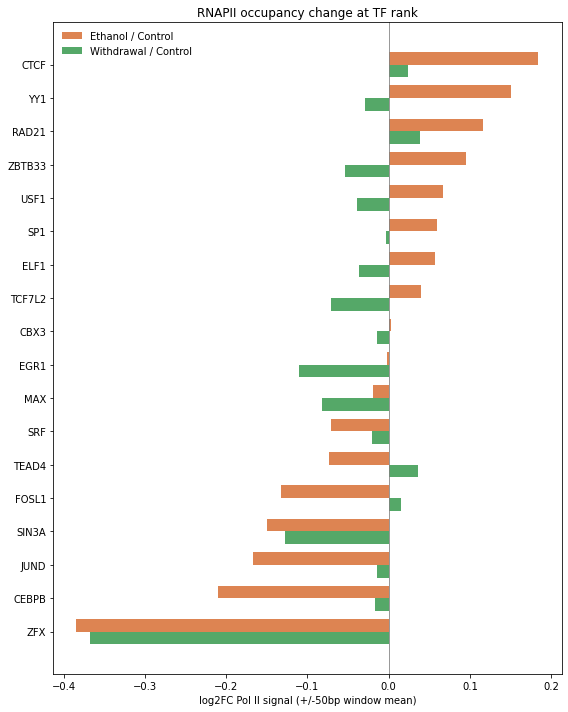

In [52]:
# ----------------------------------------------------------------------
# 6. SUPPLEMENTARY PLOT: log2FC (Ethanol/Control and Withdrawal/Control), per TF
# ----------------------------------------------------------------------
PSEUDOCOUNT = 0.1  # avoids log2(0) / divide-by-zero for low-signal TFs

log2fc_df = pd.DataFrame({
    "Ethanol": np.log2((tf_means["Ethanol"] + PSEUDOCOUNT) / (tf_means["Control"] + PSEUDOCOUNT)),
    "Withdrawal": np.log2((tf_means["Withdrawal"] + PSEUDOCOUNT) / (tf_means["Control"] + PSEUDOCOUNT)),
})

# order TFs by Ethanol log2FC, highest first -- Withdrawal bars follow the same order
log2fc_df = log2fc_df.sort_values("Ethanol", ascending=False)
tf_order_fc = log2fc_df.index.tolist()

y = np.arange(len(tf_order_fc))
bar_width = 0.38
fc_palette = {"Ethanol": "#DD8452", "Withdrawal": "#55A868"}

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(y - bar_width / 2, log2fc_df["Ethanol"], height=bar_width, color=fc_palette["Ethanol"], label="Ethanol / Control")
ax.barh(y + bar_width / 2, log2fc_df["Withdrawal"], height=bar_width, color=fc_palette["Withdrawal"], label="Withdrawal / Control")

ax.axvline(0, color="grey", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(tf_order_fc)
ax.invert_yaxis()  # highest Ethanol log2FC at the top
ax.set_xlabel("log2FC Pol II signal (+/-50bp window mean)")
ax.set_title("RNAPII occupancy change at TF rank")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("RNAPII_log2FC_ethanol_withdrawal_vs_control_at_TF_rank.pdf", dpi=300)
plt.show()

In [54]:
"""
Read a deepTools computeMatrix .gz matrix (reference-point mode, TF peaks as
region groups, Pol II conditions as samples), pull the signal value at the
peak center for every peak, average per TF, z-score each condition across
TFs, and plot the ranked z-scores as 'RNAPII occupancy at TF rank'.

No dependency on the deeptools python package's internal heatmapper class
(API varies across versions) -- this parses the matrix format directly,
which is stable and documented: a '@'-prefixed JSON header line followed by
tab-separated rows of [chrom, start, end, name, score, strand, bin values...].
"""

import gzip
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# >>> UPDATE THIS PATH <<<
# ----------------------------------------------------------------------
MATRIX_PATH = "peaks/pol2_allTFs.gz"

# If your --samplesLabel used different names than these, or you want
# nicer display names, map them here.
CONDITION_LABEL_MAP = {"pol2": "Control", "pol2eth": "Ethanol", "pol2ethwith": "Withdrawal"}

CONTROL_LABEL = "Control"  # must match a value in CONDITION_LABEL_MAP (or raw sample label) after mapping

# ----------------------------------------------------------------------
# 1. PARSE THE MATRIX FILE
# ----------------------------------------------------------------------
with gzip.open(MATRIX_PATH, "rt") as f:
    header_line = f.readline()
    header_json = json.loads(header_line.lstrip("@"))
    data = pd.read_csv(f, sep="\t", header=None, low_memory=False)

sample_labels_raw = header_json["sample_labels"]
sample_boundaries = header_json["sample_boundaries"]   # cumulative bin index per sample, e.g. [0,160,320,480]
group_labels = header_json["group_labels"]              # TF names, in -R file order
group_boundaries = header_json["group_boundaries"]      # cumulative row index per TF group
upstream = header_json["upstream"]
bin_size = header_json["bin size"]

sample_labels = [CONDITION_LABEL_MAP.get(s, s) for s in sample_labels_raw]

print("Sample labels found:", sample_labels_raw, "-> mapped to:", sample_labels)
print("TF groups found:", group_labels)
print(f"upstream={upstream}bp, bin_size={bin_size}bp")

if CONTROL_LABEL not in sample_labels:
    raise ValueError(
        f"CONTROL_LABEL='{CONTROL_LABEL}' not found in mapped sample labels {sample_labels}. "
        "Fix CONDITION_LABEL_MAP / CONTROL_LABEL above."
    )

N_META_COLS = 6  # chrom, start, end, name, score, strand
WINDOW_BP = 50    # +/- window around the reference point to average over

# ----------------------------------------------------------------------
# 2. EXTRACT MEAN SIGNAL IN A +/-WINDOW_BP WINDOW AROUND THE CENTER, PER SAMPLE
# ----------------------------------------------------------------------
# A single bin was tie-heavy when the bigwig's native resolution was coarser
# than the matrix binSize (many "different" bins just repeating the same
# underlying value). Averaging a small window around the reference point
# fixes that without smoothing so much that a genuinely sharp Ethanol-only
# peak gets diluted into its flanks -- 50bp is a fraction of a typical
# ChIP peak width, so real narrow signal should still come through.
center_values = {}  # {condition: np.array of length n_regions}
for i, (sample_raw, sample_label) in enumerate(zip(sample_labels_raw, sample_labels)):
    sample_upstream = upstream[i]
    sample_bin_size = bin_size[i]
    center_idx_within_sample = sample_upstream // sample_bin_size

    window_bins = max(1, WINDOW_BP // sample_bin_size)
    lo = max(0, center_idx_within_sample - window_bins)
    hi = center_idx_within_sample + window_bins  # inclusive via +1 below

    sample_start_bin = sample_boundaries[i]
    col_lo = N_META_COLS + sample_start_bin + lo
    col_hi = N_META_COLS + sample_start_bin + hi + 1  # +1 for inclusive slicing

    window_vals = data.iloc[:, col_lo:col_hi].apply(pd.to_numeric, errors="coerce")
    center_values[sample_label] = window_vals.mean(axis=1, skipna=True).values

# ----------------------------------------------------------------------
# 3. AVERAGE CENTER-BIN VALUE PER TF GROUP, PER CONDITION
# ----------------------------------------------------------------------
records = []
for g_idx, tf in enumerate(group_labels):
    row_start, row_end = group_boundaries[g_idx], group_boundaries[g_idx + 1]
    rec = {"TF": tf, "n_peaks": row_end - row_start}
    for cond, vals in center_values.items():
        rec[cond] = np.nanmean(vals[row_start:row_end])
    records.append(rec)

tf_means = pd.DataFrame(records).set_index("TF")

# Drop POLR2A (Pol II itself, not a TF of interest for this ranking)
tf_means = tf_means[~tf_means.index.str.contains("POLR2A")]

# Clean names to the part before the first underscore, e.g.
# "CBX3_ENCFF423XAH.bed" -> "CBX3", for axis labels / indexing from here on
tf_means.index = tf_means.index.str.split("_").str[0]

print(tf_means)

# ----------------------------------------------------------------------
# 4. Z-SCORE EACH CONDITION ACROSS TFs
# ----------------------------------------------------------------------
condition_cols = list(center_values.keys())
zscores = tf_means[condition_cols].apply(lambda col: (col - col.mean()) / col.std(), axis=0)
zscores.columns = [f"z_{c}" for c in zscores.columns]

# order TFs by control z-score, highest first
zscores = zscores.sort_values(f"z_{CONTROL_LABEL}", ascending=False)
tf_order = zscores.index.tolist()

print(zscores)

# ----------------------------------------------------------------------
# 5. PLOT: 'RNAPII occupancy at TF rank'
# ----------------------------------------------------------------------
palette = {"Control": "#4C72B0", "Ethanol": "#DD8452", "Withdrawal": "#55A868"}
x_positions = np.arange(len(tf_order))

fig, ax = plt.subplots(figsize=(12, 6))

# faint connecting lines per TF across conditions, to show the trend
for xi, tf in zip(x_positions, tf_order):
    ys = [zscores.loc[tf, f"z_{c}"] for c in condition_cols]
    ax.plot([xi] * len(ys), ys, color="lightgrey", linewidth=1, zorder=1)

for cond in condition_cols:
    ys = [zscores.loc[tf, f"z_{cond}"] for tf in tf_order]
    ax.scatter(x_positions, ys, label=cond, color=palette.get(cond, None), s=50, zorder=2)

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xticks(x_positions)
ax.set_xticklabels(tf_order, rotation=45, ha="right")
ax.set_ylabel("Z-scored Pol II signal at peak center")
ax.set_title("RNAPII occupancy at TF rank")
ax.legend(title="Condition", frameon=False)

plt.tight_layout()
plt.savefig("RNAPII_occupancy_at_TF_rank.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 6. SUPPLEMENTARY PLOT: log2FC (Ethanol/Control and Withdrawal/Control), per TF
# ----------------------------------------------------------------------
PSEUDOCOUNT = 0.1  # avoids log2(0) / divide-by-zero for low-signal TFs

log2fc_df = pd.DataFrame({
    "Ethanol": np.log2((tf_means["Ethanol"] + PSEUDOCOUNT) / (tf_means["Control"] + PSEUDOCOUNT)),
    "Withdrawal": np.log2((tf_means["Withdrawal"] + PSEUDOCOUNT) / (tf_means["Control"] + PSEUDOCOUNT)),
})

# order TFs by Ethanol log2FC, highest first -- Withdrawal bars follow the same order
log2fc_df = log2fc_df.sort_values("Ethanol", ascending=False)
tf_order_fc = log2fc_df.index.tolist()

y = np.arange(len(tf_order_fc))
bar_width = 0.38
fc_palette = {"Ethanol": "#DD8452", "Withdrawal": "#55A868"}

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(y - bar_width / 2, log2fc_df["Ethanol"], height=bar_width, color=fc_palette["Ethanol"], label="Ethanol / Control")
ax.barh(y + bar_width / 2, log2fc_df["Withdrawal"], height=bar_width, color=fc_palette["Withdrawal"], label="Withdrawal / Control")

ax.axvline(0, color="grey", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(tf_order_fc)
ax.invert_yaxis()  # highest Ethanol log2FC at the top
ax.set_xlabel("log2FC Pol II signal (+/-50bp window mean)")
ax.set_title("RNAPII occupancy change at TF rank")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("RNAPII_log2FC_ethanol_withdrawal_vs_control_at_TF_rank.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 7. PER-TF STATISTICS ON PER-PEAK VALUES (not the collapsed means)
# ----------------------------------------------------------------------
# center_values still holds one value PER PEAK, per condition, for all TFs
# concatenated -- group_boundaries slices out each TF's peaks from that.
# Rows are aligned across conditions (same region list from computeMatrix),
# so treat/control comparisons within a TF are paired by peak.
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

treatment_conditions = [c for c in condition_cols if c != CONTROL_LABEL]  # e.g. Ethanol, Withdrawal

stat_records = []
for g_idx, tf_raw in enumerate(group_labels):
    if "POLR2A" in tf_raw:
        continue
    tf = tf_raw.split("_")[0]
    row_start, row_end = group_boundaries[g_idx], group_boundaries[g_idx + 1]
    ctrl_vals = center_values[CONTROL_LABEL][row_start:row_end]

    for treat in treatment_conditions:
        treat_vals = center_values[treat][row_start:row_end]
        mask = ~np.isnan(treat_vals) & ~np.isnan(ctrl_vals)
        n = int(mask.sum())

        if n < 10:
            stat_records.append({"TF": tf, "Comparison": f"{treat} vs {CONTROL_LABEL}",
                                  "n_peaks": n, "median_diff": np.nan, "wilcoxon_p": np.nan})
            continue

        diffs = treat_vals[mask] - ctrl_vals[mask]
        try:
            _, p = wilcoxon(treat_vals[mask], ctrl_vals[mask])
        except ValueError:
            # all differences are zero -- wilcoxon undefined
            p = np.nan

        stat_records.append({
            "TF": tf, "Comparison": f"{treat} vs {CONTROL_LABEL}",
            "n_peaks": n, "median_diff": float(np.median(diffs)), "wilcoxon_p": p
        })

stats_df = pd.DataFrame(stat_records)

# FDR correction, done separately within each comparison (18 tests each)
stats_df["padj"] = np.nan
for comp in stats_df["Comparison"].unique():
    m = stats_df["Comparison"] == comp
    pvals = stats_df.loc[m, "wilcoxon_p"].values
    valid = ~np.isnan(pvals)
    padj = np.full(len(pvals), np.nan)
    if valid.sum() > 0:
        padj[valid] = multipletests(pvals[valid], method="fdr_bh")[1]
    stats_df.loc[m, "padj"] = padj

print(stats_df.sort_values(["Comparison", "padj"]).to_string(index=False))
stats_df.to_csv("RNAPII_TF_paired_stats.tsv", sep="\t", index=False)



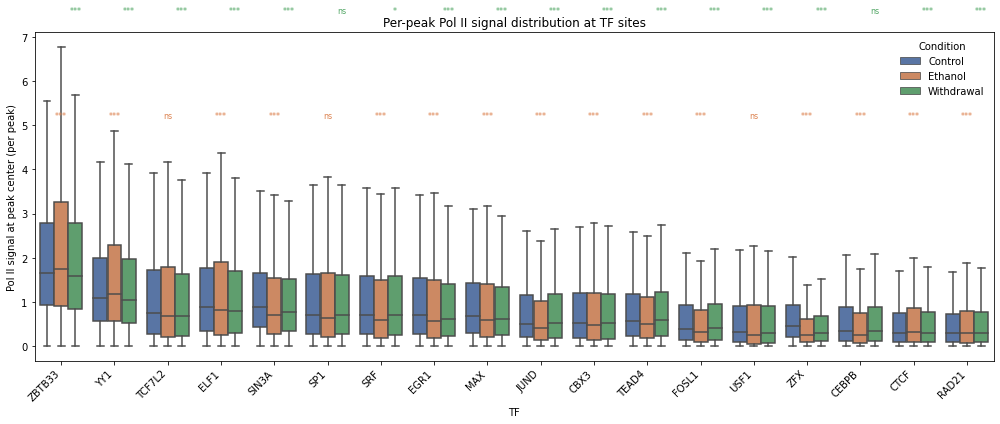

Annotated stats table -> RNAPII_TF_paired_stats_annotated.tsv
    TF            Comparison  n_peaks  median_diff    wilcoxon_p          padj sig
 CEBPB    Ethanol vs Control    17686    -0.052349  0.000000e+00  0.000000e+00 ***
  CTCF    Ethanol vs Control    52578     0.019599  0.000000e+00  0.000000e+00 ***
   ZFX    Ethanol vs Control    23434    -0.133009  0.000000e+00  0.000000e+00 ***
   YY1    Ethanol vs Control    18546     0.102219 9.526536e-289 4.286941e-288 ***
 FOSL1    Ethanol vs Control    26698    -0.041420 1.991802e-243 7.170486e-243 ***
  JUND    Ethanol vs Control    24426    -0.052507 4.178937e-240 1.253681e-239 ***
 SIN3A    Ethanol vs Control    19975    -0.102406 5.196052e-238 1.336128e-237 ***
 RAD21    Ethanol vs Control    51153     0.002156 3.873281e-184 8.714881e-184 ***
ZBTB33    Ethanol vs Control     5817     0.129137  2.839253e-75  5.678507e-75 ***
   SRF    Ethanol vs Control    10412    -0.058346  1.089752e-54  1.961553e-54 ***
   MAX    Ethanol vs Cont

In [56]:
# ----------------------------------------------------------------------
# 8. BOXPLOT OF PER-PEAK VALUES (shows the variance the means hide)
# ----------------------------------------------------------------------
long_records = []
for g_idx, tf_raw in enumerate(group_labels):
    if "POLR2A" in tf_raw:
        continue
    tf = tf_raw.split("_")[0]
    row_start, row_end = group_boundaries[g_idx], group_boundaries[g_idx + 1]
    for cond in condition_cols:
        vals = center_values[cond][row_start:row_end]
        for v in vals[~np.isnan(vals)]:
            long_records.append({"TF": tf, "Condition": cond, "Signal": v})

peak_level_df = pd.DataFrame(long_records)

import seaborn as sns
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=peak_level_df, x="TF", y="Signal", hue="Condition",
    order=tf_order,  # same TF order as the z-score rank plot, for easy comparison
    hue_order=condition_cols,
    palette=palette,
    showfliers=False,
    ax=ax,
)
ax.set_xticklabels(tf_order, rotation=45, ha="right")
ax.set_ylabel("Pol II signal at peak center (per peak)")
ax.set_title("Per-peak Pol II signal distribution at TF sites")
ax.legend(title="Condition", frameon=False)
# ----------------------------------------------------------------------
# Significance annotation for BOTH Ethanol and Withdrawal, positioned
# above each condition's own box (seaborn hue-dodge offset), not just
# a single label per TF.
# ----------------------------------------------------------------------
def sig_label(p):
    if np.isnan(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

n_hue = len(condition_cols)
box_width = 0.8 / n_hue  # seaborn's default total group width is 0.8

ymax = peak_level_df["Signal"].quantile(0.98)
ystep = (peak_level_df["Signal"].quantile(0.99) - ymax) * 1.5  # small vertical stagger so labels don't collide

for row_i, treat in enumerate(treatment_conditions):
    treat_stats = stats_df[stats_df["Comparison"] == f"{treat} vs {CONTROL_LABEL}"].set_index("TF")
    hue_index = condition_cols.index(treat)
    offset = -0.4 + box_width * (hue_index + 0.5)

    for xi, tf in enumerate(tf_order):
        if tf in treat_stats.index and not np.isnan(treat_stats.loc[tf, "padj"]):
            label = sig_label(treat_stats.loc[tf, "padj"])
            ax.text(xi + offset, ymax + row_i * ystep, label, ha="center", fontsize=8, color=palette.get(treat, "black"))

plt.tight_layout()
plt.savefig("RNAPII_per_peak_signal_by_TF_boxplot.pdf", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# Write an annotated, human-readable stats table alongside the raw one
# ----------------------------------------------------------------------
stats_df["sig"] = stats_df["padj"].apply(sig_label)
stats_annotated_path = "RNAPII_TF_paired_stats_annotated.tsv"
stats_df.sort_values(["Comparison", "padj"]).to_csv(stats_annotated_path, sep="\t", index=False)
print(f"Annotated stats table -> {stats_annotated_path}")
print(stats_df.sort_values(["Comparison", "padj"]).to_string(index=False))

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
